# Assignment 3: Visualizing Error Surfaces and Optimization Behavior

## Step 1: Data and Model Preparation
### Step 1.1: Load and Preprocess MNIST

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping

# For Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Original train shape:", x_train.shape)
print("Original test shape:", x_test.shape)

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# LeNet-5 originally uses 32x32, so pad 28x28 -> 32x32
x_train = np.pad(x_train, ((0,0), (2,2), (2,2)), mode='constant')
x_test = np.pad(x_test, ((0,0), (2,2), (2,2)), mode='constant')

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)   # (60000, 32, 32, 1)
x_test = np.expand_dims(x_test, axis=-1)     # (10000, 32, 32, 1)

print("Processed train shape:", x_train.shape)
print("Processed test shape:", x_test.shape)
print("Train labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Original train shape: (60000, 28, 28)
Original test shape: (10000, 28, 28)
Processed train shape: (60000, 32, 32, 1)
Processed test shape: (10000, 32, 32, 1)
Train labels shape: (60000,)
Test labels shape: (10000,)


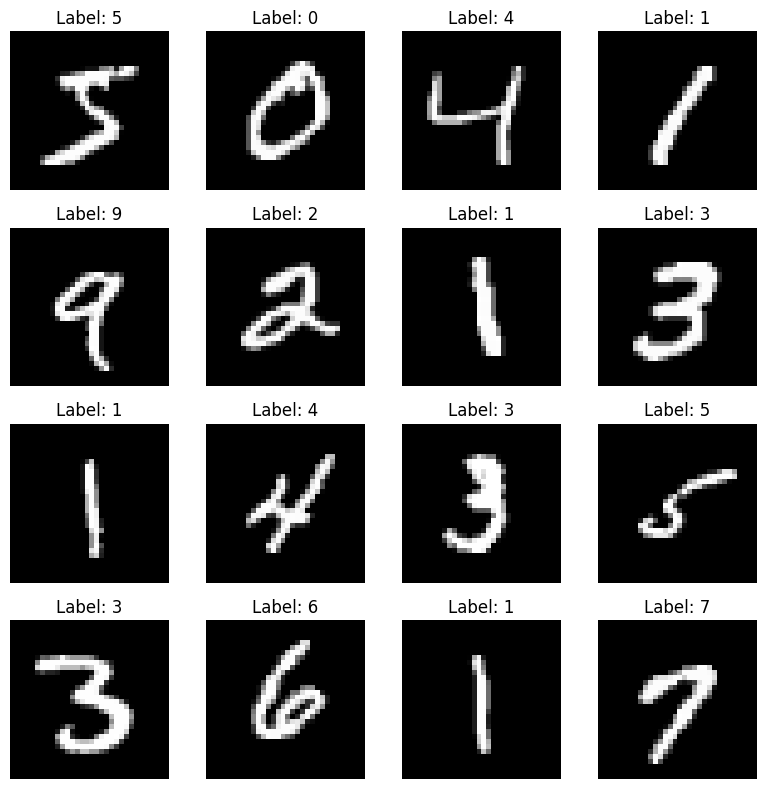

In [ ]:
# Display 16 sample images
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Step 1.2: Implement LeNet-5

In [ ]:
def build_lenet5():
    inputs = Input(shape=(32, 32, 1))

    x = layers.Conv2D(6, kernel_size=(5, 5), activation='tanh')(inputs)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)

    x = layers.Conv2D(16, kernel_size=(5, 5), activation='tanh')(x)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)

    x = layers.Conv2D(120, kernel_size=(5, 5), activation='tanh')(x)

    x = layers.Flatten()(x)
    x = layers.Dense(84, activation='tanh')(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name="LeNet5")
    return model

model = build_lenet5()
model.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Save initial weights before training
initial_weights = model.get_weights()

## Step 2: Model Training

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=12,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 65ms/step - accuracy: 0.8073 - loss: 0.6643 - val_accuracy: 0.9593 - val_loss: 0.1450
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9497 - loss: 0.1647 - val_accuracy: 0.9737 - val_loss: 0.0945
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.9690 - loss: 0.1034 - val_accuracy: 0.9780 - val_loss: 0.0745
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9775 - loss: 0.0739 - val_accuracy: 0.9820 - val_loss: 0.0631
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.9830 - loss: 0.0557 - val_accuracy: 0.9832 - val_loss: 0.0570
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.9866 - loss: 0.0439 - val_accuracy: 0.9830 - val_loss: 0.0542
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - accuracy: 0.9896 - loss: 0.0347 - val_accuracy: 0.9827 - val_loss: 0.0543
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.9919 - loss: 0.0282 - 

### Plot Training & Validation loss

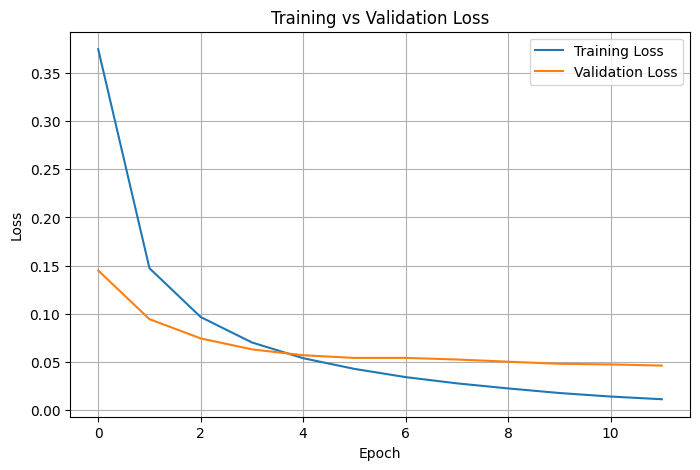

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Determine a reasonable stopping epoch

In [ ]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
print("Reasonable stopping epoch:", best_epoch)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Reasonable stopping epoch: 12
Test Loss: 0.0462
Test Accuracy: 0.9859


### Save final weights

In [ ]:
final_weights = model.get_weights()

# Save trained weights for reuse
model.save_weights("lenet5_mnist.weights.h5")
print("Weights saved to lenet5_mnist.weights.h5")

Weights saved to lenet5_mnist.weights.h5


## Step 3: Error Surface Studies (1D Directional Analysis)

In [ ]:
def interpolate_weights(weights_a, weights_b, alpha):
    """Linear interpolation between two weight sets."""
    return [(1 - alpha) * wa + alpha * wb for wa, wb in zip(weights_a, weights_b)]

def evaluate_loss_for_weights(model, weights, x_data, y_data, batch_size=256):
    """Set weights, then evaluate loss on a dataset."""
    model.set_weights(weights)
    loss, acc = model.evaluate(x_data, y_data, batch_size=batch_size, verbose=0)
    return loss, acc

In [ ]:
# Small subset for faster loss surface analysis
subset_size = 2000
x_surface = x_test[:subset_size]
y_surface = y_test[:subset_size]

print("Using subset for error surface:", x_surface.shape, y_surface.shape)

Using subset for error surface: (2000, 32, 32, 1) (2000,)


In [ ]:
alphas = np.linspace(-0.5, 1.5, 41)

surface_losses = []
surface_accs = []

for alpha in alphas:
    interp_w = interpolate_weights(initial_weights, final_weights, alpha)
    loss, acc = evaluate_loss_for_weights(model, interp_w, x_surface, y_surface)
    surface_losses.append(loss)
    surface_accs.append(acc)
    print(f"alpha={alpha:.2f} -> loss={loss:.4f}, acc={acc:.4f}")

alpha=-0.50 -> loss=2.7972, acc=0.0390
alpha=-0.45 -> loss=2.7120, acc=0.0415
alpha=-0.40 -> loss=2.6011, acc=0.0470
alpha=-0.35 -> loss=2.4896, acc=0.0500
alpha=-0.30 -> loss=2.4014, acc=0.0420
alpha=-0.25 -> loss=2.3486, acc=0.0260
alpha=-0.20 -> loss=2.3319, acc=0.0945
alpha=-0.15 -> loss=2.3430, acc=0.0780
alpha=-0.10 -> loss=2.3651, acc=0.0050
alpha=-0.05 -> loss=2.3720, acc=0.0005
alpha=0.00 -> loss=2.3327, acc=0.0650
alpha=0.05 -> loss=2.2214, acc=0.2315
alpha=0.10 -> loss=2.0369, acc=0.2680
alpha=0.15 -> loss=1.8136, acc=0.3005
alpha=0.20 -> loss=1.5938, acc=0.3405
alpha=0.25 -> loss=1.3830, acc=0.4150
alpha=0.30 -> loss=1.1608, acc=0.5060
alpha=0.35 -> loss=0.9231, acc=0.6050
alpha=0.40 -> loss=0.6896, acc=0.7130
alpha=0.45 -> loss=0.4872, acc=0.8125
alpha=0.50 -> loss=0.3334, acc=0.8805
alpha=0.55 -> loss=0.2289, acc=0.9215
alpha=0.60 -> loss=0.1631, acc=0.9450
alpha=0.65 -> loss=0.1234, acc=0.9610
alpha=0.70 -> loss=0.0998, acc=0.9670
alpha=0.75 -> loss=0.0857, acc=0.9720
al

Plot the 1D error surface

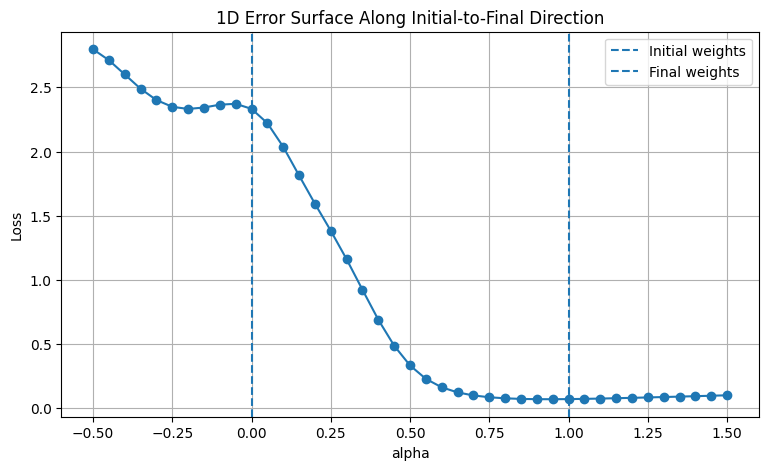

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(alphas, surface_losses, marker='o')
plt.axvline(x=0.0, linestyle='--', label='Initial weights')
plt.axvline(x=1.0, linestyle='--', label='Final weights')
plt.xlabel("alpha")
plt.ylabel("Loss")
plt.title("1D Error Surface Along Initial-to-Final Direction")
plt.legend()
plt.grid(True)
plt.show()

Optional accuracy plot

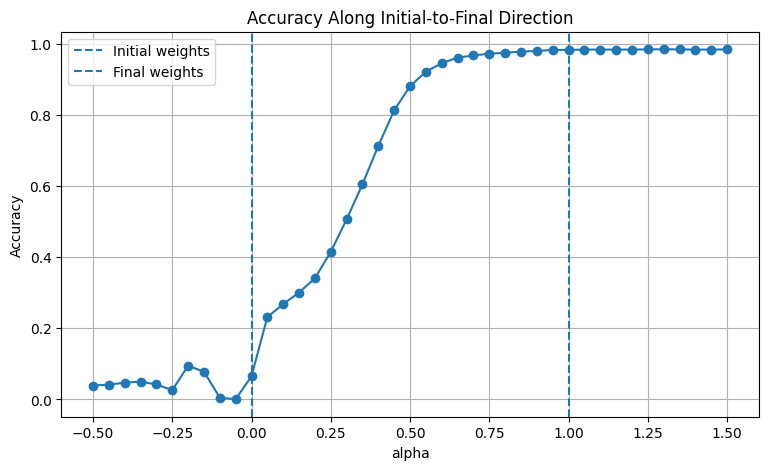

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(alphas, surface_accs, marker='o')
plt.axvline(x=0.0, linestyle='--', label='Initial weights')
plt.axvline(x=1.0, linestyle='--', label='Final weights')
plt.xlabel("alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy Along Initial-to-Final Direction")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.set_weights(final_weights)
print("Final trained weights restored.")

Final trained weights restored.
